# Vortex Induced Vibrations


In [453]:
import numpy as np
import matplotlib.pyplot as plt


L = 50.0
D = 0.5
rho_w = 1025
rho_c = 7880
T = 30000
b = 126
St = 0.21

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a
omega_n = (np.pi / L) * np.sqrt(T / m_eff)
zeta = b / (2 * omega_n * m_eff)

epsilon = 0.3
A_coupling = 12.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0


In [454]:
def rhs(t, x, U):

    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    # Lift 
    Lift = 0.5 * rho_w * U**2 * D * L * q

    # Structural 
    y_ddot = (-2*zeta*omega_n*y_dot - omega_n**2*y + Lift/m_eff)

    # Wake 
    q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [455]:
def rk4(f, t, x, dt, U):

    k1 = f(t, x, U)
    k2 = f(t + dt/2, x + dt/2 * k1, U)
    k3 = f(t + dt/2, x + dt/2 * k2, U)
    k4 = f(t + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [456]:
def comp_x(dt, t_end, U):
    time = np.arange(0, t_end, dt)
    x = np.array([0.01, 0.0, 0.0, 0.0])
    solution = np.zeros((len(time), 4))

    for i, t in enumerate(time):
        solution[i] = x
        x = rk4(rhs, t, x, dt, U)
    
    print(x)

    return time, solution

In [457]:
def compute_amplitude(U):

    time, solution = comp_x(dt , t_end, U)

    y = solution[:,2]

    # Remove transient (last 30%)
    cutoff = int(0.7 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5*(np.max(y_steady) - np.min(y_steady))

    return amplitude

In [458]:
def simulate_velocity(dt, t_end, U):
    time = np.arange(0, t_end, dt)

    x = np.array([0.01, 0.0, 0.0, 0.0])

    y_history = []
    time , solution = comp_x(dt, t_end, U)
    
    for t in time:
        y_history.append(x[2])
        x = rk4(rhs, t, x, dt, U)

    y_history = np.array(y_history)

    cutoff = int(0.7 * len(solution))
    y_steady = y_history[cutoff:]

    amplitude = 0.5 * (np.max(y_steady) - np.min(y_steady))

    return amplitude

[-1.24135902e+00  1.35213416e+00  1.61151915e-04 -2.03272528e-04]
[-1.24135902e+00  1.35213416e+00  1.61151915e-04 -2.03272528e-04]
Amplitude for U=0.03 m/s: 0.28 mm
[-1.91394287e+00 -6.29610889e-01  2.19046007e-03  9.07444536e-04]
[-1.91394287e+00 -6.29610889e-01  2.19046007e-03  9.07444536e-04]
Amplitude for U=0.09 m/s: 2.51 mm
[ 1.93031173e+00 -4.77707115e-01 -7.06934552e-03  1.16703058e-03]
[ 1.93031173e+00 -4.77707115e-01 -7.06934552e-03  1.16703058e-03]
Amplitude for U=0.15 m/s: 7.17 mm
[-1.68741768 -1.18580697  0.01103087  0.00811778]
[-1.68741768 -1.18580697  0.01103087  0.00811778]
Amplitude for U=0.21 m/s: 14.64 mm
[-1.87520111  0.58690146  0.02320235 -0.00605842]
[-1.87520111  0.58690146  0.02320235 -0.00605842]
Amplitude for U=0.27 m/s: 25.54 mm
Simulation completed in 4.09 seconds.


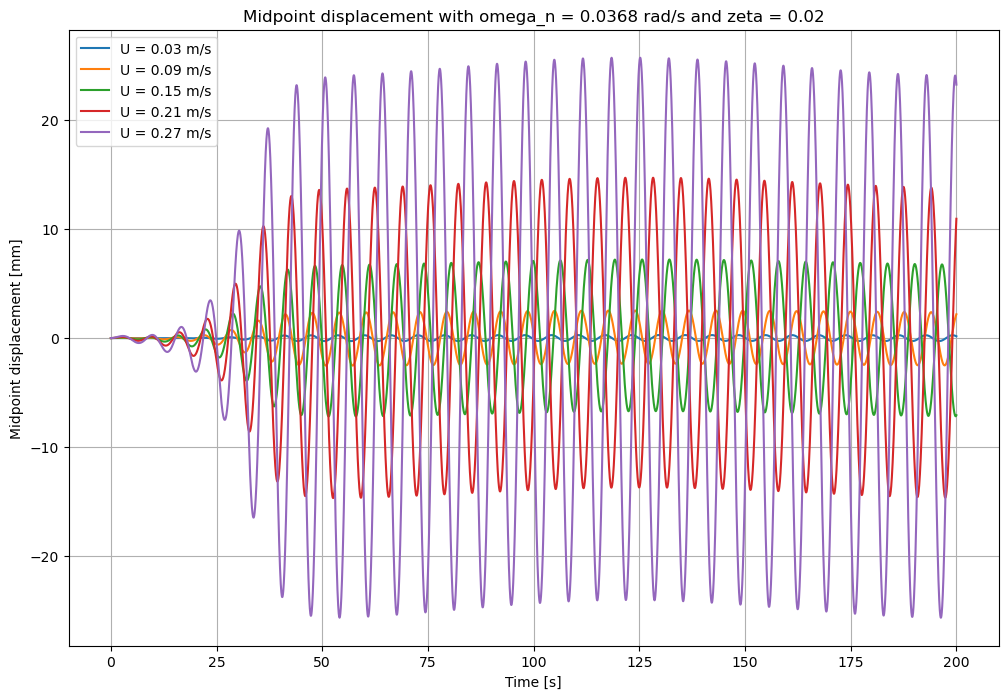

In [459]:
U_range = np.linspace(0.03, 0.27, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    time, solution = comp_x(dt, t_end, U)
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    print(f"Amplitude for U={U:.2f} m/s: {simulate_velocity(dt, t_end, U)*1000:.2f} mm")

end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")


plt.xlabel("Time [s]")
plt.title(f"Midpoint displacement with omega_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
plt.ylabel("Midpoint displacement [mm]")
plt.legend()
plt.grid()
plt.show()

Solving for U = 0.030
[-1.24135902e+00  1.35213416e+00  1.61151915e-04 -2.03272528e-04]
Solving for U = 0.090
[-1.91394287e+00 -6.29610889e-01  2.19046007e-03  9.07444536e-04]
Solving for U = 0.150
[ 1.93031173e+00 -4.77707115e-01 -7.06934552e-03  1.16703058e-03]
Solving for U = 0.210
[-1.68741768 -1.18580697  0.01103087  0.00811778]
Solving for U = 0.270
[-1.87520111  0.58690146  0.02320235 -0.00605842]


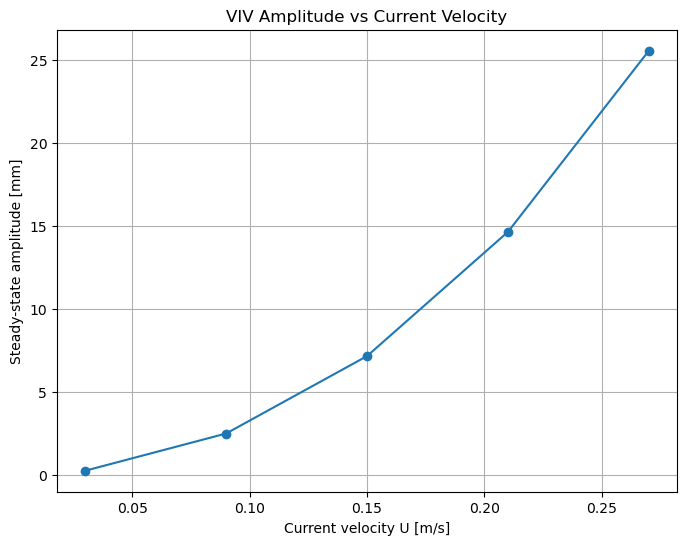

In [465]:
U_values = np.linspace(0.03, 0.27, 5)
amplitudes = []

for U in U_values:
    print(f"Solving for U = {U:.3f}")
    amp = compute_amplitude(U)
    amplitudes.append(amp)

plt.figure(figsize=(8,6))
plt.plot(U_values, 1000 * np.array(amplitudes), marker='o')
plt.xlabel("Current velocity U [m/s]")
plt.ylabel("Steady-state amplitude [mm]")
plt.title("VIV Amplitude vs Current Velocity")
plt.grid(True)
plt.show()